# Fermi fitting development/testing

In [1]:
%reset -f
%run pylib/tools dark
from pylib.tools import np, plt, pd
from pathlib import Path
from importlib import reload
from astropy.coordinates import SkyCoord
from utilities.ipynb_docgen import show, show_date
from like3 import pixel_table as pixel_table_mod; reload(pixel_table_mod)
PixelTable = pixel_table_mod.PixelTable
from like3 import sourcelist as sourcelist_mod; reload(sourcelist_mod)
SourceModel = sourcelist_mod.SourceModel
from like3 import main as main_mod; reload(main_mod)
FermiFit = main_mod.FermiFit
show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-04-15 13:51</h5>

In [3]:
roi_name, cone_size = 'Geminga', 1.0
roi_center = SkyCoord.from_name(roi_name)
roi_sources = SourceModel.from_fermi_catalog('v40', #'uw1617',
    skydir=roi_center,
    cone_size=cone_size,
    query='significance >= 25',
)
selected_name = roi_sources.source_names[0]
show(
    f'''Loaded {len(roi_sources)} catalog sources within {cone_size} deg of {roi_center.to_string("decimal", precision=3)}.
First selected source: {selected_name}''')
pt = PixelTable('files/kerr/toby_v4.fits', source_model=roi_sources)


Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries


Loaded 1 catalog sources within 1.0 deg of 98.476 17.770.
First selected source: FL16Y J0633.9+1746

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, np.int64(4)): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, np.int64(11)): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 1 sources to pixel table
set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from 'files/loc'


## FermiFit devel.

Name                  index     value  error(%)
FL16Y J0633.9+1746_N*     0 2.709e-10       ***
                  _I*     1     2.043       ***


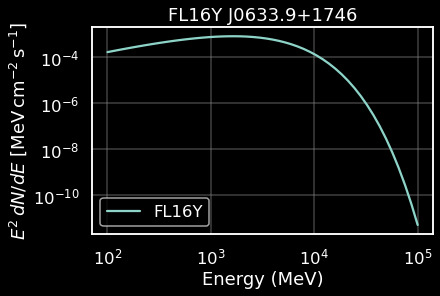

In [43]:
reload(main_mod)
FermiFit = main_mod.FermiFit
reload(pixel_table_mod)
PixelTable = pixel_table_mod.PixelTable
ff = FermiFit(pt)
src = roi_sources[0]
fig, ax = plt.subplots(figsize=(6,4))
src.sed_plot(ax=ax, label='FL16Y')

ff.summary()  


In [43]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pytest', '-q',
     'tests/test_pixel_table_model.py', 'tests/test_pixel_table_exposure.py'],
    capture_output=True, text=True,
    cwd='/home/burnett/work/pixel-table'
)
lines = result.stdout.strip().split('\n')
# Show just the last 15 lines (summary line + recent failures)
print('\n'.join(lines[-15:]))
if result.returncode != 0:
    print('\n--- stderr ---')
    print(result.stderr[-1000:])

......................................                                   [100%]
38 passed in 1.80s


loglike at fit point x0=[-9.53262757, 2.04285955]: 396503.478182
scan maximum at x[0] = -9.5722  (expected ~ -9.5)
ll at scan max = 396723.4308,  delta from fit point = 219.952657
ll range across scan: 748.7006


/tmp/ipykernel_119990/1407244080.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


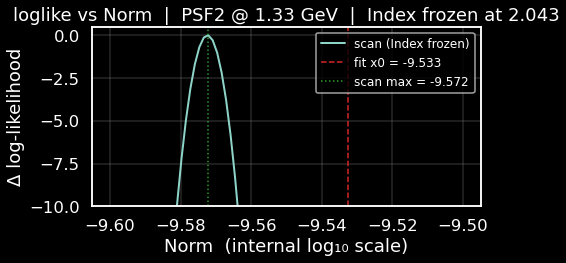

In [5]:
pt.select((2,4))

# Restore both parameters to the fit values first so each evaluation
# starts from a well-defined state.
pset = ff.parameters
x0_vals = [-9.53262757, 2.04285955]   # internal fit values (log10 norm, index)
pset.set_parameters(x0_vals)
ll_at_fit = ff.loglike()
print(f'loglike at fit point x0={x0_vals}: {ll_at_fit:.6f}')

# Scan Norm (parameter 0) holding Index (parameter 1) frozen at its fit value.
x_scan = np.linspace(-9.60, -9.5, 80)
ll_scan = []
for xi in x_scan:
    pset.set_parameters([xi, x0_vals[1]])
    ll_scan.append(ff.loglike())

# Restore fit parameters after scan
pset.set_parameters(x0_vals)

ll_scan = np.array(ll_scan)
i_max = np.argmax(ll_scan)
print(f'scan maximum at x[0] = {x_scan[i_max]:.4f}  (expected ~ -9.5)')
print(f'll at scan max = {ll_scan[i_max]:.4f},  delta from fit point = {ll_scan[i_max] - ll_at_fit:.6f}')
print(f'll range across scan: {ll_scan.max() - ll_scan.min():.4f}')

plt.figure(figsize=(7, 4))
plt.plot(x_scan, ll_scan - ll_scan.max(), lw=2, label='scan (Index frozen)')
plt.axvline(x0_vals[0], color='tab:red',   ls='--', lw=1.5, label=f'fit x0 = {x0_vals[0]:.3f}')
plt.axvline(x_scan[i_max], color='tab:green', ls=':',  lw=1.5, label=f'scan max = {x_scan[i_max]:.3f}')
plt.xlabel('Norm  (internal log₁₀ scale)')
plt.ylabel('Δ log-likelihood')
plt.title('loglike vs Norm  |  PSF2 @ 1.33 GeV  |  Index frozen at 2.043')
plt.ylim(-10, 0.5)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

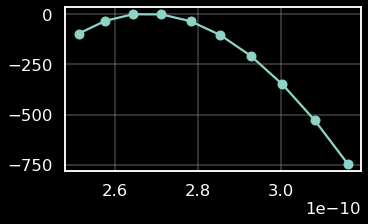

In [26]:
def flux_ll(x):
    def _eval_scalar(xi):
        pset.set_parameters([np.log10(max(float(xi), 1e-13)), x0_vals[1]])
        return ff.loglike()

    x_arr = np.asarray(x)
    if x_arr.ndim == 0:
        return float(_eval_scalar(x_arr.item()))

    vals = np.array([_eval_scalar(xi) for xi in x_arr], dtype=float)
    return vals

x_scan = np.logspace(-9.60, -9.5, 10)
y_series = [flux_ll(x) for x in x_scan]
y_scan = np.array(y_series); y_scan -= y_scan.max()  # normalize to max for plotting
plt.plot(x_scan, y_scan, marker='o')

In [32]:
from like3.loglikelihood import Poisson, PoissonFitter
flux_ref = 10**x0_vals[0]

def flux_ll_u(u):
    u_arr = np.asarray(u)
    if u_arr.ndim == 0:
        return float(flux_ll(max(float(u_arr.item()), 0.0) * flux_ref))
    return np.array([flux_ll(max(float(ui), 0.0) * flux_ref) for ui in u_arr], dtype=float)

pf = PoissonFitter(flux_ll_u, scale=1.0, delta=1e-3)

# Convert Poisson(u) parameters back to Poisson(flux) parameters with u = flux/flux_ref.
sp_u, e_u, b_u = pf.poiss.p
outfun = Poisson([flux_ref * sp_u, e_u / flux_ref, flux_ref * b_u])
outfun

like3.loglikelihood.Poisson: 2.6767345407766017e-10[1+0.00-0.00

In [ ]:
outfun.errors, outfun

(2.6648784291573563e-10, 2.6886227598746835e-10)

In [ ]:
x_scan = np.linspace(-9.60, -9.5, 10)
y_scan = flux_fun(x_scan)
print(y_scan)
plt.loglog(x_scan, y_scan , lw=2)


/home/burnett/miniconda3/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


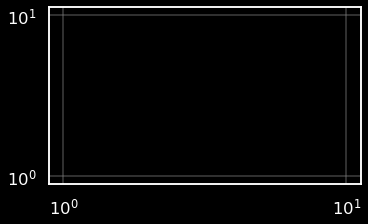

In [ ]:
flux_ref = 10**x0_vals[0]
index_ref = x0_vals[1]

def flux_fun(u):
    def _eval_scalar(ui):
        flux = max(float(ui), 0.0) * flux_ref
        pset.set_parameters([np.log10(max(flux, 1e-13)), index_ref])
        return ff.loglike()

    u_arr = np.asarray(u)
    if u_arr.ndim == 0:
        return float(_eval_scalar(u_arr.item()))

    return np.array([_eval_scalar(ui) for ui in u_arr], dtype=float)


In [70]:
y_scan

array([14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977,
       14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977,
       14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977,
       14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977,
       14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977,
       14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977,
       14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977,
       14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977,
       14703485.5008977, 14703485.5008977, 14703485.5008977, 14703485.5008977, 1

In [ ]:

from like3.loglikelihood import PoissonFitter
pf = PoissonFitter(flux_fun, scale=flux_ref, delta=1e-3*flux_ref)
pf, pf.poiss

In [65]:
flux_fun(flux_ref)

14703485.500897704

show_selected: 42 band(s), scope=all bands (no active selection)
    key label  emin_mev  emax_mev  energy_mev  nside   nocc
 (0, 4)  PSF0      1000      1778        1333     64  49195
 (0, 5)  PSF0      1778      3162        2371     64  49152
 (0, 6)  PSF0      3162      5623        4216    128 180405
 (0, 7)  PSF0      5623     10000        7498    128 144473
 (0, 8)  PSF0     10000     17782       13335    128  97993
 (0, 9)  PSF0     17782     31622       23713    256  72060
(0, 10)  PSF0     31622     56234       42169    256  34948
(0, 11)  PSF0     56234    100000       74989    256  15665
 (1, 2)  PSF1       316       562         421     32  12288
 (1, 3)  PSF1       562      1000         749     64  49152
 (1, 4)  PSF1      1000      1778        1333    128 196464
 (1, 5)  PSF1      1778      3162        2371    256 597768
 (1, 6)  PSF1      3162      5623        4216    256 425755
 (1, 7)  PSF1      5623     10000        7498    512 370760
 (1, 8)  PSF1     10000     17782  

show_selected: 42 band(s), scope=all bands (no active selection)
    key label  emin_mev  emax_mev  energy_mev  nside   nocc
 (0, 4)  PSF0      1000      1778        1333     64  49195
 (0, 5)  PSF0      1778      3162        2371     64  49152
 (0, 6)  PSF0      3162      5623        4216    128 180405
 (0, 7)  PSF0      5623     10000        7498    128 144473
 (0, 8)  PSF0     10000     17782       13335    128  97993
 (0, 9)  PSF0     17782     31622       23713    256  72060
(0, 10)  PSF0     31622     56234       42169    256  34948
(0, 11)  PSF0     56234    100000       74989    256  15665
 (1, 2)  PSF1       316       562         421     32  12288
 (1, 3)  PSF1       562      1000         749     64  49152
 (1, 4)  PSF1      1000      1778        1333    128 196464
 (1, 5)  PSF1      1778      3162        2371    256 597768
 (1, 6)  PSF1      3162      5623        4216    256 425755
 (1, 7)  PSF1      5623     10000        7498    512 370760
 (1, 8)  PSF1     10000     17782  

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x78b0d7709be0>
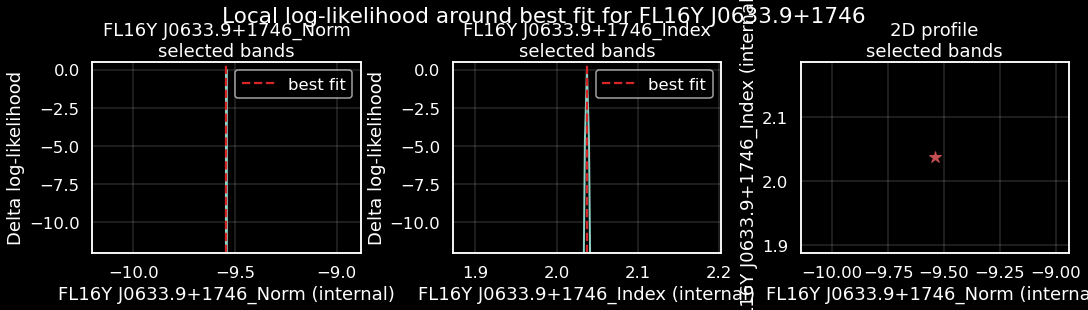

{'hess': array([[5170559.26431143, 1819322.27652926],
        [1819322.27652926, 1536795.52417529]]),
 'cov': array([[ 3.31480347e-07, -3.92420182e-07],
        [-3.92420182e-07,  1.11526794e-06]]),
 'sigs': array([0.0006, 0.0011]),
 'corr': array([[ 1.  , -0.65],
        [-0.65,  1.  ]]),
 'grad': array([ 0.04421692, -0.10457852]),
 'x_fit': array([-9.54197755,  2.03727751]),
 'x_init': array([-9.53262757,  2.04285955]),
 'delta_loglike': 341.65,
 'ts_values': array([6287537.3,       nan]),
 'param_mask': array([ True,  True])}

In [45]:
# make a plot of the likelihood function about its current best fit parameters
pt.select()
selected = pt.show_selected()

with ff.preserve_parameters():
    ff.fit()
    fit_info = ff.fit_info.copy()
    pset = ff.parameters
    x0 = np.array(pset.get_parameters(), dtype=float)
    names = np.asarray(ff.parameter_names)[fit_info.get('param_mask', np.ones(len(x0), dtype=bool))]
    sigs = np.asarray(fit_info.get('sigs', np.ones_like(x0)), dtype=float)

    # Use the reported curvature scale when it is finite and local; otherwise
    # fall back to a small internal-space window so the profile remains readable.
    widths = np.where(np.isfinite(sigs) & (sigs > 1e-3) & (sigs < 1.0), 2.5 * sigs, 0.6)
    widths = np.clip(widths, 0.15, 1.0)

    def scan_loglike(i, grid):
        vals = []
        for xi in grid:
            trial = x0.copy()
            trial[i] = xi
            pset.set_parameters(trial)
            vals.append(ff.loglike())
        pset.set_parameters(x0)
        return np.asarray(vals)

    npar = len(x0)
    ncols = npar + (1 if npar >= 2 else 0)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4), constrained_layout=True)
    axes = np.atleast_1d(axes)

    band_label = 'selected bands'
    if len(selected) == 1:
        row = selected.iloc[0]
        band_label = f"{row['label']} @ {row['energy_mev']:.0f} MeV"

    for i, (name, width) in enumerate(zip(names, widths)):
        grid = np.linspace(x0[i] - width, x0[i] + width, 121)
        loglike = scan_loglike(i, grid)
        dloglike = loglike - loglike.max()
        ax_i = axes[i]
        ax_i.plot(grid, dloglike, lw=2)
        ax_i.axvline(x0[i], color='tab:red', ls='--', label='best fit')
        ax_i.set_xlabel(f'{name} (internal)')
        ax_i.set_ylabel('Delta log-likelihood')
        ax_i.set_title(f'{name}\n{band_label}')
        ax_i.grid(True, alpha=0.3)
        ax_i.set_ylim(-12, 0.5)
        ax_i.legend()

    if npar >= 2:
        xg = np.linspace(x0[0] - widths[0], x0[0] + widths[0], 61)
        yg = np.linspace(x0[1] - widths[1], x0[1] + widths[1], 61)
        z = np.empty((len(yg), len(xg)))
        for iy, yv in enumerate(yg):
            for ix, xv in enumerate(xg):
                trial = x0.copy()
                trial[0] = xv
                trial[1] = yv
                pset.set_parameters(trial)
                z[iy, ix] = ff.loglike()
        pset.set_parameters(x0)
        z = z - z.max()

        ax2d = axes[-1]
        cs = ax2d.contour(xg, yg, z, levels=[-9, -4.5, -2, -0.5], cmap='viridis')
        ax2d.clabel(cs, fmt='%.1f')
        ax2d.plot(x0[0], x0[1], 'r*', ms=12)
        ax2d.set_xlabel(f'{names[0]} (internal)')
        ax2d.set_ylabel(f'{names[1]} (internal)')
        ax2d.set_title(f'2D profile\n{band_label}')
        ax2d.grid(True, alpha=0.3)

    fig.suptitle(f'Local log-likelihood around best fit for {src.name}', y=1.04)
    show(fig)

show(ff.fit_info)

In [46]:
with ff.preserve_parameters() as ctx:
    ff.fit()
    src.sed_plot(ax=ax, label='fit')
    new_flux_func = src.model.copy()
    ctx.restore = False
    
show(ff.fit_info)
ff.summary()

{'hess': array([[5170559.26431143, 1819322.27652926],
        [1819322.27652926, 1536795.52417529]]),
 'cov': array([[ 3.31480347e-07, -3.92420182e-07],
        [-3.92420182e-07,  1.11526794e-06]]),
 'sigs': array([0.0006, 0.0011]),
 'corr': array([[ 1.  , -0.65],
        [-0.65,  1.  ]]),
 'grad': array([ 0.04421692, -0.10457852]),
 'x_fit': array([-9.54197755,  2.03727751]),
 'x_init': array([-9.53262757,  2.04285955]),
 'delta_loglike': 341.65,
 'ts_values': array([6287537.3,       nan]),
 'param_mask': array([ True,  True])}

Name                  index     value  error(%)  gradient        TS
FL16Y J0633.9+1746_N*     0 2.871e-10       0.1       0.0   6287537
                  _I*     1     2.037       0.1      -0.1          


In [47]:
# --- Norm prof: fit only the normalization for each aenergy bin ---
# Group all bands by energy index (second element of band key); each group
# contains up to 4 PSF-type bands that share the same energy boundaries.


energy_indices = sorted({k[1] for k in pt.keys()})
src = ff.source_model[0] # the source we just fit above; should be the same as roi_sources[0]
flux_func = src.model.copy()
rows = []
with ff.preserve_parameters():
    for keys in pt.bands_by_energy.values():
        pt.select(keys=keys)
        ff.fit('_Norm')
        band0 = pt[keys[0]]
        e_mev = np.sqrt(band0.e0 * band0.e1).astype(int)
        x_fit  = ff.fit_info['x_fit'][0]
        
        # Compute reasonable uncertainties with regularization
        # When Hessian is very small (< 1e-20), use relative error floor of 20%
        hess_val = ff.fit_info['hess'][0, 0]
        if np.abs(hess_val) > 1e-20:
            sig = np.sqrt(1.0 / np.abs(hess_val))
        else:
            # Use 20% relative uncertainty floor when unconstrained
            sig = np.abs(x_fit) * 0.2
        
        # Clamp to reasonable range: between 1% relative and 100% relative
        min_sig = np.abs(x_fit) * 0.01
        max_sig = np.abs(x_fit) * 1.0
        sig = np.clip(sig, min_sig, max_sig)
        
        ts_val = ff.fit_info['ts_values'][0]
        rows.append(dict(e_mev=e_mev, x_fit=x_fit.round(3), sig=sig.round(3), 
                         ts=ts_val, sed=flux_func(e_mev)*e_mev**2))

pt.select()   # reset to all bands
prof = pd.DataFrame(rows)
show(prof)

,e_mev,x_fit,sig,ts,sed
0,133,-9.541,0.095,166521.3,2.243780e-04
1,237,-9.548,0.095,371415.2,3.572459e-04
2,421,-9.541,0.095,913926.7,5.327432e-04
3,749,-9.535,0.095,1268395.0,7.245642e-04
4,1333,-9.550,0.095,1646505.5,8.586345e-04
5,2371,-9.529,0.095,1183725.8,8.299173e-04
6,4216,-9.554,0.096,557815.8,5.939634e-04
7,7498,-9.564,0.096,155327.4,2.726311e-04
8,13335,-9.511,0.095,22785.6,6.492121e-05
9,23713,-9.185,0.092,1487.9,5.866556e-06


In [48]:
# for the selected source, return the normalization likelihood function in external units.
Lnorm = ff.norm_profile(src)
print(Lnorm)

pt.select()
lo, hi = Lnorm.errors
x = np.logspace(np.log10(max(lo * 0.7, 1e-12)), np.log10(hi * 1.3), 120)
y = Lnorm(x)

plt.figure(figsize=(6,4))
plt.plot(x, y - y.max())
plt.xscale('log')
plt.xlabel('Flux normalization (ph/cm^2/s)')
plt.ylabel('Delta log-likelihood')
plt.title(f'Normalization likelihood profile for {src.name}')
plt.ylim(-10, 1)
plt.grid(True, which='both', ls='--')
plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

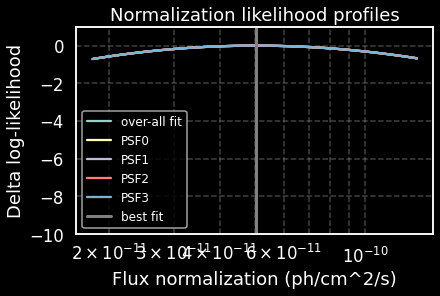

{(0, 4): Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001,
 (0, 5): Band(0, 5): PSF0@2.37 GeV nside 64 occ 1.000,
 (0, 6): Band(0, 6): PSF0@4.22 GeV nside 128 occ 0.918,
 (0, 7): Band(0, 7): PSF0@7.50 GeV nside 128 occ 0.735,
 (0, 8): Band(0, 8): PSF0@13.34 GeV nside 128 occ 0.498,
 (0, 9): Band(0, 9): PSF0@23.71 GeV nside 256 occ 0.092,
 (0, 10): Band(0, 10): PSF0@42.17 GeV nside 256 occ 0.044,
 (0, 11): Band(0, 11): PSF0@74.99 GeV nside 256 occ 0.020,
 (1, 2): Band(1, 2): PSF1@0.42 GeV nside 32 occ 1.000,
 (1, 3): Band(1, 3): PSF1@0.75 GeV nside 64 occ 1.000,
 (1, 4): Band(1, 4): PSF1@1.33 GeV nside 128 occ 0.999,
 (1, 5): Band(1, 5): PSF1@2.37 GeV nside 256 occ 0.760,
 (1, 6): Band(1, 6): PSF1@4.22 GeV nside 256 occ 0.541,
 (1, 7): Band(1, 7): PSF1@7.50 GeV nside 512 occ 0.118,
 (1, 8): Band(1, 8): PSF1@13.34 GeV nside 512 occ 0.055,
 (1, 9): Band(1, 9): PSF1@23.71 GeV nside 512 occ 0.024,
 (1, 10): Band(1, 10): PSF1@42.17 GeV nside 512 occ 0.011,
 (1, 11): Band(1, 11): PSF1@74.99 GeV n

In [ ]:
plt.figure(figsize=(6,4))

norm_fit = Lnorm.flux
lo, hi = Lnorm.errors
x = np.logspace(np.log10(max(lo * 0.85, 1e-12)), np.log10(hi * 1.15), 120)

pt.select(emin=1000, emax=1200)
y = Lnorm(x)
plt.plot(x, y - y.max(), label='over-all fit')
plt.title('Normalization likelihood profiles')

for ie in range(4):
    pt.select((ie, 4))
    y = Lnorm(x)
    plt.plot(x, y - y.max(), label=f'PSF{ie}')

plt.gca().axvline(norm_fit, color='grey', ls='-', lw=3, label='best fit')
plt.xscale('log')
plt.xlabel('Flux normalization (ph/cm^2/s)')
plt.ylabel('Delta log-likelihood')
plt.ylim(-10, 1)
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=12)
plt.show()
pt.select();

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7b89bea6b9d0>
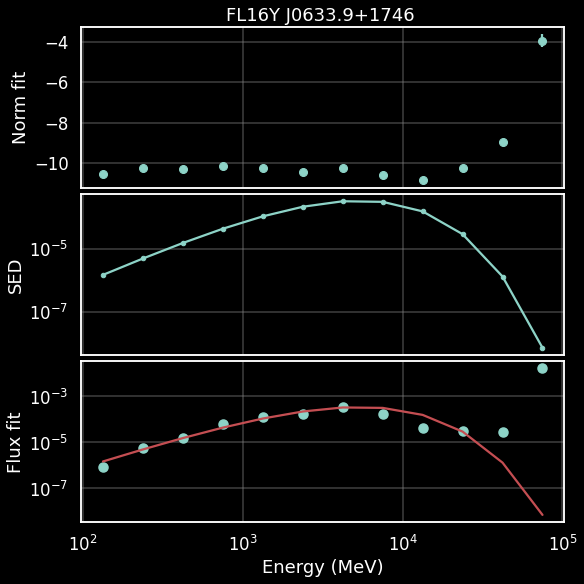

In [ ]:
fig, axx = plt.subplots(3,1, figsize=(8,8), sharex=True)
ax,ax2,ax3 = axx
ax.errorbar(prof['e_mev'], prof['x_fit'], yerr=prof['sig'], fmt='o', markersize=8)
ax.set_xscale('log')
# ax2.set_xlabel('Energy (MeV)')
ax.set_ylabel('Norm fit')
ax.set_title(f'{selected_name} ')
e_mev = prof['e_mev']
ax2.plot(prof['e_mev'], prof['sed'], '.-', )#label='FL16Y SED')
# ax2.plot(prof['e_mev'], e_mev**2 * new_flux_func(e_mev), '+', label='Norm fit SED')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylabel('SED')#r'$E^2\,dN/dE\ [\mathrm{MeV\,cm^{-2}\,s^{-1}}]$')
# ax2.legend()
ax3.scatter(prof.e_mev, 10**prof.x_fit * prof.sed/flux_func['Norm'], )# label='flux fit')
ax3.plot(prof['e_mev'], e_mev**2 * new_flux_func(e_mev), 'r', label='Norm fit SED')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_ylabel('Flux fit')
ax3.set_xlabel('Energy (MeV)')
# ax3.legend()
show(fig)

In [ ]:

# Table of norm_profile fits (Poisson.flux) divided by the overall-fit flux,
# for each individual band and for all PSF types combined at each energy.

overall_flux = Lnorm.flux
psf_types = sorted({k[0] for k in pt.keys()})

def _ratio_str(poiss, denom):
    """Return 'ratio ± half_err' or '< 95% limit' formatted string."""
    if poiss.flux <= 0:
        return f'< {poiss.limit / denom:.3f}'
    r = poiss.flux / denom
    lo, hi = poiss.errors
    err = (hi - lo) / (2.0 * denom)
    return f'{r:.3f} ± {err:.3f}'

def _safe_profile(keys_sel, tol=2.0):
    """Return norm_profile for the given selection, or None on failure."""
    pt.select(keys=keys_sel)
    try:
        return ff.norm_profile(src, tol=tol)
    except Exception:
        return None

rows = []
with ff.preserve_parameters():
    for e_idx, keys_e in pt.bands_by_energy.items():
        band0 = pt[keys_e[0]]
        e_mev = int(np.sqrt(band0.e0 * band0.e1))
        row = dict(e_mev=e_mev)

        # One norm_profile per individual band (PSF type)
        for key in keys_e:
            psf_idx = key[0]
            poiss = _safe_profile([key])
            row[f'PSF{psf_idx}'] = _ratio_str(poiss, overall_flux) if poiss else 'N/A'

        # norm_profile with all PSF types combined at this energy
        poiss_all = _safe_profile(keys_e)
        row['All'] = _ratio_str(poiss_all, overall_flux) if poiss_all else 'N/A'

        rows.append(row)

pt.select()
band_table = pd.DataFrame(rows).set_index('e_mev')['PSF0 PSF1 PSF2 PSF3 All'.split()]
show(band_table)


,PSF0,PSF1,PSF2,PSF3,All
e_mev,,,,,
133,NaN,NaN,0.626 ± 0.489,0.573 ± 0.536,0.598 ± 0.446
237,NaN,NaN,1.130 ± 1.070,1.123 ± 1.064,1.126 ± 1.083
421,NaN,0.541 ± 0.369,2.210 ± 2.050,2.200 ± 2.104,1.054 ± 0.805
749,NaN,1.062 ± 0.643,1.083 ± 0.957,4.197 ± 2.805,1.398 ± 1.088
1333,0.512 ± 0.353,1.955 ± 1.480,1.877 ± 1.618,8.075 ± 4.248,1.154 ± 1.281
2371,0.262 ± 0.196,3.860 ± 2.502,3.867 ± 2.935,15.728 ± 8.332,0.751 ± 0.722
4216,0.413 ± 0.244,1.854 ± 0.717,7.411 ± 1.488,7.550 ± 3.693,1.079 ± 0.885
7498,0.173 ± 0.003,3.818 ± 0.064,3.715 ± 0.066,3.511 ± 0.065,0.530 ± 0.304
13335,0.086 ± 0.004,2.061 ± 0.089,9.091 ± 0.401,7.802 ± 0.376,0.275 ± 0.006


In [ ]:
rows = []
with ff.preserve_parameters():
    for e_idx, keys_e in pt.bands_by_energy.items():
        band0 = pt[keys_e[0]]
        e_mev = int(np.sqrt(band0.e0 * band0.e1))
        row = dict(e_mev=e_mev)

        # One norm_profile per individual band (PSF type)
        for key in keys_e:
            psf_idx = key[0]
            poiss = _safe_profile([key])
            row[f'PSF{psf_idx}'] = poiss# _ratio_str(poiss, overall_flux) if poiss else 'N/A'

        # norm_profile with all PSF types combined at this energy
        poiss_all = _safe_profile(keys_e)
        row['All'] = poiss_all #_ratio_str(poiss_all, overall_flux) if poiss_all else 'N/A'

        rows.append(row)

pt.select()
poiss_table = pd.DataFrame(rows).set_index('e_mev')['PSF0 PSF1 PSF2 PSF3 All'.split()]
show(poiss_table)

,PSF0,PSF1,PSF2,PSF3,All
e_mev,,,,,
133,NaN,NaN,"LogNormProfile(flux=3.146e-11, errors=(1.543e-11, 6.46e-11), ts=12059.88)","LogNormProfile(flux=2.877e-11, errors=(1.256e-11, 6.643e-11), ts=6998.78)","LogNormProfile(flux=3.005e-11, errors=(1.516e-11, 5.997e-11), ts=18460.01)"
237,NaN,NaN,"LogNormProfile(flux=5.675e-11, errors=(2.461e-11, 1.321e-10), ts=11186.96)","LogNormProfile(flux=5.64e-11, errors=(2.441e-11, 1.313e-10), ts=6764.73)","LogNormProfile(flux=5.658e-11, errors=(2.428e-11, 1.331e-10), ts=8245.58)"
421,NaN,"LogNormProfile(flux=2.72e-11, errors=(1.444e-11, 5.152e-11), ts=35281.18)","LogNormProfile(flux=1.11e-10, errors=(4.882e-11, 2.548e-10), ts=10300.56)","LogNormProfile(flux=1.105e-10, errors=(4.758e-11, 2.59e-10), ts=8547.88)","LogNormProfile(flux=5.294e-11, errors=(2.632e-11, 1.072e-10), ts=31704.73)"
749,NaN,"LogNormProfile(flux=5.336e-11, errors=(3.019e-11, 9.478e-11), ts=57141.29)","LogNormProfile(flux=5.442e-11, errors=(2.47e-11, 1.209e-10), ts=11013.46)","LogNormProfile(flux=2.109e-10, errors=(1.132e-10, 3.951e-10), ts=38431.06)","LogNormProfile(flux=7.022e-11, errors=(3.453e-11, 1.438e-10), ts=27398.39)"
1333,"LogNormProfile(flux=2.574e-11, errors=(1.359e-11, 4.903e-11), ts=21045.95)","LogNormProfile(flux=9.823e-11, errors=(4.91e-11, 1.978e-10), ts=19084.91)","LogNormProfile(flux=9.431e-11, errors=(4.348e-11, 2.06e-10), ts=9069.61)","LogNormProfile(flux=4.057e-10, errors=(2.456e-10, 6.725e-10), ts=50237.02)","LogNormProfile(flux=5.798e-11, errors=(2.248e-11, 1.512e-10), ts=6162.98)"
2371,"LogNormProfile(flux=1.316e-11, errors=(6.625e-12, 2.63e-11), ts=18418.50)","LogNormProfile(flux=1.939e-10, errors=(1.058e-10, 3.572e-10), ts=32304.96)","LogNormProfile(flux=1.943e-10, errors=(9.696e-11, 3.919e-10), ts=18469.56)","LogNormProfile(flux=7.902e-10, errors=(4.769e-10, 1.314e-09), ts=63252.06)","LogNormProfile(flux=3.775e-11, errors=(1.621e-11, 8.873e-11), ts=8627.04)"
4216,"LogNormProfile(flux=2.075e-11, errors=(1.187e-11, 3.643e-11), ts=37455.26)","LogNormProfile(flux=9.312e-11, errors=(6.391e-11, 1.36e-10), ts=150485.83)","LogNormProfile(flux=3.723e-10, errors=(3.051e-10, 4.546e-10), ts=1050605.68)","LogNormProfile(flux=3.793e-10, errors=(2.372e-10, 6.083e-10), ts=45444.95)","LogNormProfile(flux=5.423e-11, errors=(2.583e-11, 1.147e-10), ts=17021.06)"
7498,"LogNormProfile(flux=8.669e-12, errors=(8.529e-12, 8.81e-12), ts=189169010.58)","LogNormProfile(flux=1.918e-10, errors=(1.887e-10, 1.951e-10), ts=137738730.57)","LogNormProfile(flux=1.866e-10, errors=(1.834e-10, 1.9e-10), ts=207453698.80)","LogNormProfile(flux=1.764e-10, errors=(1.732e-10, 1.797e-10), ts=64258944.67)","LogNormProfile(flux=2.665e-11, errors=(1.548e-11, 4.605e-11), ts=20430.34)"
13335,"LogNormProfile(flux=4.299e-12, errors=(4.123e-12, 4.483e-12), ts=3709125.50)","LogNormProfile(flux=1.035e-10, errors=(9.917e-11, 1.081e-10), ts=8650868.45)","LogNormProfile(flux=4.567e-10, errors=(4.37e-10, 4.773e-10), ts=5777580.09)","LogNormProfile(flux=3.92e-10, errors=(3.736e-10, 4.113e-10), ts=3929071.65)","LogNormProfile(flux=1.384e-11, errors=(1.353e-11, 1.415e-11), ts=9012651.32)"


In [ ]:
t = poiss_table.iloc[11,0]; t.flux/overall_flux, np.array(t.errors)/overall_flux

(2253310.3684907965, array([ 669104.15975258, 7614071.88134296]))

,elow,ehigh,flux,lflux,uflux,ts,maxdev
energy,,,,,,,
133,100.000000,177.827941,225.610796,224.729184,226.494484,2.275688e+05,0.000730
237,177.827941,316.227766,352.345267,351.253684,353.438964,4.295351e+05,0.000522
421,316.227766,562.341325,NaN,NaN,NaN,NaN,NaN
749,562.341325,1000.000000,736.104735,734.435404,737.776514,1.030855e+06,0.000039
1333,1000.000000,1778.279410,NaN,NaN,NaN,NaN,NaN
2371,1778.279410,3162.277660,855.189291,852.756463,857.626448,5.120941e+05,0.000258
4216,3162.277660,5623.413252,577.957965,575.391595,580.531559,2.264083e+05,0.000319
7498,5623.413252,10000.000000,259.328293,257.103703,261.565672,1.814836e+05,0.000295
13335,10000.000000,17782.794100,69.740088,68.219598,71.282286,1.099677e+04,0.000439


/tmp/ipykernel_119990/615283869.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


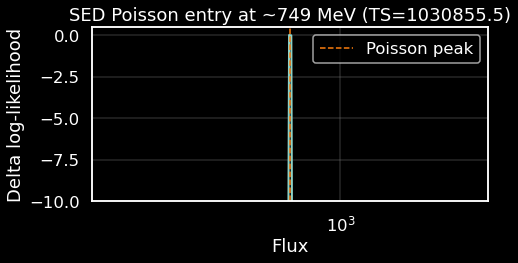

In [46]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Kernel may still hold an older FermiFit class without legacy aliases.
if not hasattr(ff, 'sources'):
    ff.__class__.sources = property(lambda self: self.source_model)
if not hasattr(ff, 'bands'):
    ff.__class__.bands = property(lambda self: self.pixel_table)

sedfuns = importlib.import_module('like3.sedfuns')
sedfuns = importlib.reload(sedfuns)

if hasattr(ff, 'get_sed_poisson_table'):
    sedp = ff.get_sed_poisson_table(source_name=selected_name, tol=0.2)
else:
    sedp = sedfuns.sed_poisson_table(ff, source_name=selected_name, tol=0.2)

display(sedp[['elow', 'ehigh', 'flux', 'lflux', 'uflux', 'ts', 'maxdev']])

valid = sedp[sedp.poiss.notna()]
if len(valid) == 0:
    print('No valid Poisson entries found in SED table.')
else:
    row = valid.sort_values('ts', ascending=False).iloc[0]
    p = row.poiss

    f0 = max(float(row.flux), 1e-20)
    f_lo = max(float(row.lflux), 1e-20) if np.isfinite(row.lflux) else f0 / 3.0
    f_hi = float(row.uflux) if np.isfinite(row.uflux) else f0 * 3.0
    lo = max(min(f_lo, f0 / 3.0), 1e-20)
    hi = max(f_hi, f0 * 3.0, lo * 1.5)

    flux_grid = np.geomspace(lo, hi, 160)
    dll = p(flux_grid)
    dll = dll - np.max(dll)

    plt.figure(figsize=(7, 4))
    plt.plot(flux_grid, dll, lw=2)
    plt.axvline(float(row.flux), color='tab:orange', ls='--', lw=1.5, label='Poisson peak')
    plt.xscale('log')
    plt.ylim(-10, 0.5)
    plt.xlabel('Flux')
    plt.ylabel('Delta log-likelihood')
    plt.title(f'SED Poisson entry at ~{int(row.name)} MeV (TS={row.ts:.1f})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [47]:
import numpy as np
import pandas as pd

# Build (or reuse) the SED Poisson table.
if 'sedp' not in globals() or sedp is None:
    sedp = ff.get_sed_poisson_table(source_name=selected_name, tol=0.2)

valid = sedp[sedp.poiss.notna()]
if len(valid) == 0:
    print('No valid Poisson entries found in SED table.')
else:
    row = valid.sort_values('ts', ascending=False).iloc[0]
    p = row.poiss
    elow, ehigh = float(row.elow), float(row.ehigh)

    # Recreate the same band selection used for this SED bin.
    chosen = [
        b for b in ff.pixel_table.values()
        if float(b.e0) >= elow and float(b.e1) <= ehigh
    ]

    # Choose test points around the Poisson peak.
    f_peak = max(float(row.flux), 1e-20)
    f_lo = float(row.lflux) if np.isfinite(row.lflux) and row.lflux > 0 else f_peak * 0.85
    f_hi = float(row.uflux) if np.isfinite(row.uflux) and row.uflux > 0 else f_peak * 1.15
    flux_pts = np.array(sorted({max(f_lo, 1e-20), f_peak, max(f_hi, 1e-20)}), dtype=float)

    saved_keys = ff.pixel_table._selected
    efv = ff.energy_flux_view(selected_name, bound=-20)
    try:
        ff.pixel_table.select(keys=[b.key for b in chosen])
        efv.set_energy(np.sqrt(elow * ehigh))

        ll_direct = np.array([float(efv(f)) for f in flux_pts], dtype=float)
        ll_poiss = np.array([float(p(f)) for f in flux_pts], dtype=float)

        d_direct = ll_direct - ll_direct.max()
        d_poiss = ll_poiss - ll_poiss.max()
        d_diff = d_direct - d_poiss

        cmp = pd.DataFrame({
            'flux': flux_pts,
            'direct_dll': d_direct,
            'poiss_dll': d_poiss,
            'difference': d_diff,
        })
        display(cmp)
        print(f"Max |difference| = {np.max(np.abs(d_diff)):.3e} for bin ~{int(row.name)} MeV")
    finally:
        ff.pixel_table.select(keys=saved_keys)
        if hasattr(efv, 'restore'):
            efv.restore()

,flux,direct_dll,poiss_dll,difference
0,734.435404,-0.499937,-0.5,0.000063
1,736.104735,0.000000,0.0,0.000000
2,737.776514,-0.500063,-0.5,-0.000063


Max |difference| = 6.322e-05 for bin ~749 MeV


In [50]:
import numpy as np
import pandas as pd

# Delta-likelihood decomposition using per-band Poisson likelihood functions.
# We compare a perturbed model (Norm scaled by alpha) against the reference model.
alpha = 1.05

with ff.preserve_parameters():
    ff.fit()

    if 'sedp' not in globals() or sedp is None:
        sedp = ff.get_sed_poisson_table(source_name=selected_name, tol=0.2)

    valid = sedp[sedp.poiss.notna()].copy()
    if len(valid) == 0:
        print('No valid Poisson entries found in SED table.')
    else:
        src = ff.source_model.find_source(selected_name)
        norm0 = float(src.model.getp('Norm'))

        saved_keys = pt._selected
        efv = ff.energy_flux_view(selected_name, bound=-20)
        rows = []

        try:
            # Per-band Poisson deltas at reference vs perturbed model prediction.
            for e_idx, row in valid.sort_index().iterrows():
                elow, ehigh = float(row.elow), float(row.ehigh)
                chosen = [
                    b for b in pt.values()
                    if float(b.e0) >= elow and float(b.e1) <= ehigh
                ]
                if len(chosen) == 0:
                    continue

                pt.select(keys=[b.key for b in chosen])
                efv.set_energy(np.sqrt(elow * ehigh))

                flux_ref = float(efv.eflux)
                flux_test = alpha * flux_ref

                dll_poiss = float(row.poiss(flux_test) - row.poiss(flux_ref))
                rows.append(dict(
                    energy=e_idx,
                    elow=elow,
                    ehigh=ehigh,
                    flux_ref=flux_ref,
                    flux_test=flux_test,
                    dll_poiss=dll_poiss,
                ))

            band_delta_df = pd.DataFrame(rows)
            sum_dll_poiss = float(band_delta_df.dll_poiss.sum())

            # All-band direct delta for the same norm scaling.
            pt.select(keys=saved_keys)
            src.model.setp('Norm', norm0)
            src.changed = True
            ll_ref_all = float(ff.loglike())

            src.model.setp('Norm', alpha * norm0)
            src.changed = True
            ll_test_all = float(ff.loglike())

            dll_all_direct = ll_test_all - ll_ref_all

        finally:
            src.model.setp('Norm', norm0)
            src.changed = True
            pt.select(keys=saved_keys)
            if hasattr(efv, 'restore'):
                efv.restore()

        show(band_delta_df[['energy', 'flux_ref', 'flux_test', 'dll_poiss']])
        print(f'alpha (Norm scale):                              {alpha:.6f}')
        print(f'Sum of per-band Poisson deltas:                 {sum_dll_poiss:.6f}')
        print(f'All-band direct delta log-likelihood:           {dll_all_direct:.6f}')
        print(f'Difference (sum_poiss_delta - all_band_delta):  {sum_dll_poiss - dll_all_direct:.6e}')

,energy,flux_ref,flux_test,dll_poiss
0,133,224.881017,236.125068,-68.681100
1,237,357.402768,375.272907,-200.993278
2,749,724.935575,761.182353,-87.682581
3,2371,829.879711,871.373697,33.207133
4,4216,593.838574,623.530503,-131.034671
5,7498,272.567701,286.196086,-50.838890
6,13335,64.917816,68.163707,4.653743
7,23713,5.865594,6.158874,4.069670
8,56234,0.008877,0.009320,0.130839


alpha (Norm scale):                              1.050000
Sum of per-band Poisson deltas:                 -497.169136
All-band direct delta log-likelihood:           -1164.979246
Difference (sum_poiss_delta - all_band_delta):  6.678101e+02
